In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Определение целевой функции и ее производной
def f(x):
    return 0.5 * x**2 - np.sin(x)

def df(x):
    return x - np.cos(x)

def cubic_approximation(f, df, a, b, eps=0.0001, max_iter=10):
    iterations = []
    
    for i in range(max_iter):
        x0, x1 = a, b
        y0, y1 = f(x0), f(x1)
        d0, d1 = df(x0), df(x1)
        delta = x1 - x0
        
        if abs(delta) < eps:
            break
            
        # Коэффициенты по методичке
        A_const = y0
        B_const = d0 + 2*y0/delta
        C_const = y1
        D_const = -d1 + 2*y1/delta
        
        # Коэффициенты многочлена H(x) = a3*x^3 + a2*x^2 + a1*x + a0
        a3 = B_const - D_const
        a2 = (A_const - B_const*x0 - 2*B_const*x1) + (C_const + D_const*x1 + 2*D_const*x0)
        a1 = (-2*A_const + 2*B_const*x0 + B_const*x1)*x1 + (-2*C_const - 2*D_const*x1 - D_const*x0)*x0
        a0 = (A_const - B_const*x0)*x1**2 + (C_const + D_const*x1)*x0**2
        
        # Поиск минимума многочлена (корни 3*a3*x^2 + 2*a2*x + a1 = 0)
        if abs(a3) < 1e-12: # Случай квадратичной аппроксимации
            xm = -a1 / (2 * a2)
        else:
            discr = (2*a2)**2 - 4*(3*a3)*a1
            if discr < 0: # Защита от отрицательного дискриминанта
                xm = (a + b) / 2
            else:
                sqrt_d = np.sqrt(discr)
                roots = [(-2*a2 + sqrt_d) / (6*a3), (-2*a2 - sqrt_d) / (6*a3)]
                # Выбираем корень внутри интервала
                xm = [r for r in roots if x0 <= r <= x1][0]
        
        # Сохраняем данные для визуализации
        iterations.append({
            'a': x0, 'b': x1, 'xm': xm, 
            'poly': lambda x, a3=a3, a2=a2, a1=a1, a0=a0: a3*x**3 + a2*x**2 + a1*x + a0
        })
        
        # Проверка условия остановки
        if abs(df(xm)) < eps:
            break
            
        # Обновление границ
        if df(xm) < 0:
            a = xm
        else:
            b = xm
            
    return xm, iterations

# Запуск алгоритма
x_min, history = cubic_approximation(f, df, 0, 1)

print(f"Найденный минимум: x ≈ {x_min:.6f}")
print(f"Значение функции: f(x) ≈ {f(x_min):.6f}")
print(f"Значение производной: f'(x) ≈ {df(x_min):.6e}")

Найденный минимум: x ≈ 0.739110
Значение функции: f(x) ≈ -0.400489
Значение производной: f'(x) ≈ 4.213522e-05


Вычислеие итерации 1...
Вычислеие итерации 2...


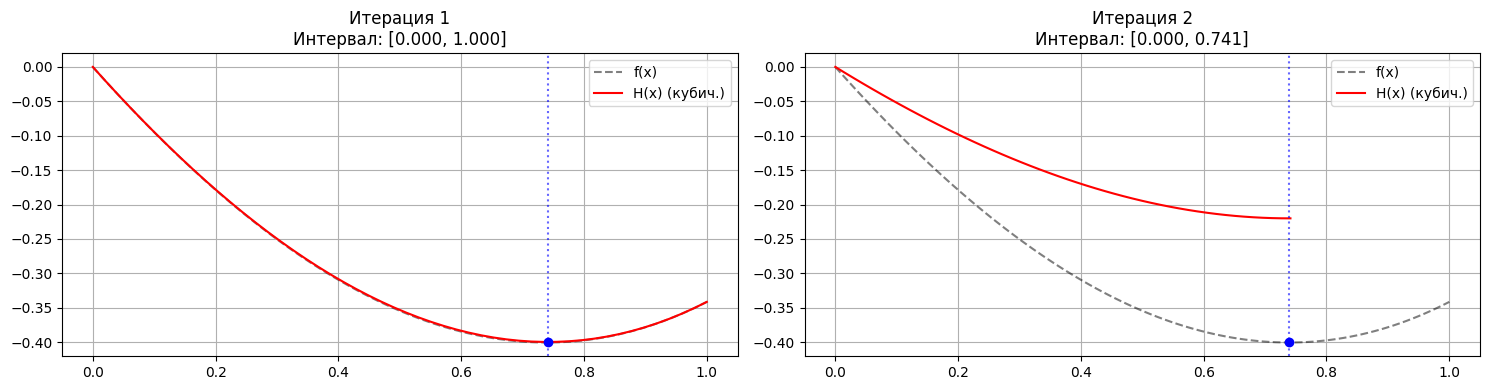

In [ ]:
def plot_iterations(f, history):
    n = min(len(history), 3)  # Покажем первые 3 итерации
    fig, axes = plt.subplots(1, n, figsize=(15, 4))

    x_range = np.linspace(0, 1, 100)
    y_true = f(x_range)

    for i in range(n):
        print(f"Вычислеие итерации {i+1}...")
        ax = axes[i]
        step = history[i]

        # Истинная функция
        ax.plot(x_range, y_true, "k--", label="f(x)", alpha=0.5)

        # Аппроксимирующий многочлен на текущем интервале [a, b]
        x_local = np.linspace(step["a"], step["b"], 50)
        y_poly = [step["poly"](xi) for xi in x_local]
        ax.plot(x_local, y_poly, "r", label="H(x) (кубич.)")

        # Точка минимума на итерации
        ax.scatter(step["xm"], f(step["xm"]), color="blue", zorder=5)
        ax.axvline(step["xm"], color="blue", linestyle=":", alpha=0.6)

        ax.set_title(f"Итерация {i+1}\nИнтервал: [{step['a']:.3f}, {step['b']:.3f}]")
        ax.legend()
        ax.grid(True)
        


plot_iterations(f, history)
plt.tight_layout()
plt.show()

Iter 1: xm = 0.741294, f'(xm) = 3.698554e-03
Iter 2: xm = 0.739110, f'(xm) = 4.213522e-05


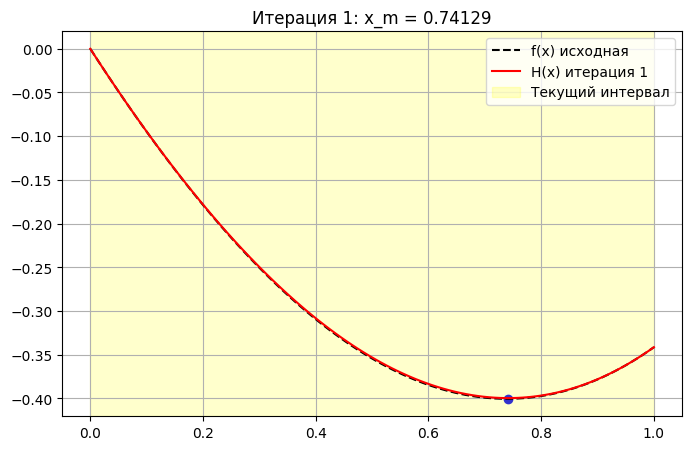

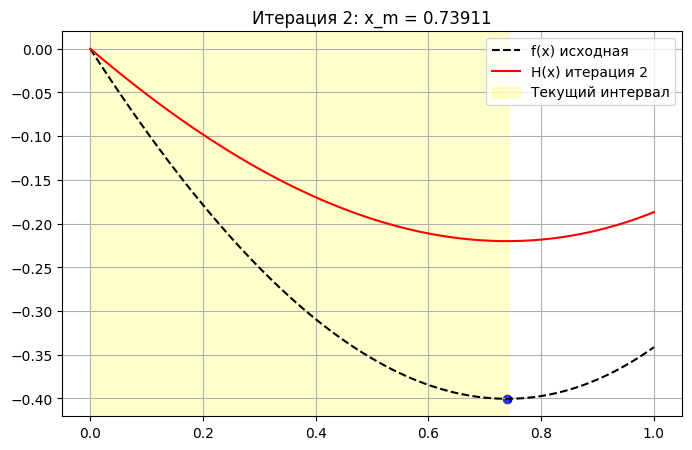

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return 0.5 * x**2 - np.sin(x)


def df(x):
    return x - np.cos(x)


def solve():
    a, b = 0.0, 1.0
    eps = 0.0001
    history = []

    for iter_num in range(1, 11):
        x0, x1 = a, b
        y0, y1, d0, d1 = f(x0), f(x1), df(x0), df(x1)
        delta = x1 - x0

        # Расчет коэффициентов A, B, C, D
        A, B = y0, d0 + 2 * y0 / delta
        C, D = y1, -d1 + 2 * y1 / delta

        # Коэффициенты канонического вида
        a3 = B - D
        a2 = (A - B * x0 - 2 * B * x1) + (C + D * x1 + 2 * D * x0)
        a1 = (-2 * A + 2 * B * x0 + B * x1) * x1 + (-2 * C - 2 * D * x1 - D * x0) * x0
        a0 = (A - B * x0) * x1**2 + (C + D * x1) * x0**2

        # Поиск корня производной H'(x)
        discr = (2 * a2) ** 2 - 4 * (3 * a3) * a1
        xm = (-2 * a2 + np.sqrt(discr)) / (6 * a3)

        history.append({"a": a, "b": b, "xm": xm, "coeffs": (a3, a2, a1, a0)})

        print(f"Iter {iter_num}: xm = {xm:.6f}, f'(xm) = {df(xm):.6e}")

        if abs(df(xm)) < eps:
            break

        if df(xm) < 0:
            a = xm
        else:
            b = xm

    return history


history = solve()

# Визуализация каждой итерации
for i, step in enumerate(history):
    plt.figure(figsize=(8, 5))
    x_plot = np.linspace(0, 1, 100)
    plt.plot(x_plot, f(x_plot), "k--", label="f(x) исходная")

    a3, a2, a1, a0 = step["coeffs"]
    h_x = a3 * x_plot**3 + a2 * x_plot**2 + a1 * x_plot + a0
    plt.plot(x_plot, h_x, "r", label=f"H(x) итерация {i+1}")

    plt.scatter(step["xm"], f(step["xm"]), color="blue")
    plt.axvspan(
        step["a"], step["b"], color="yellow", alpha=0.2, label="Текущий интервал"
    )
    plt.title(f"Итерация {i+1}: x_m = {step['xm']:.5f}")
    plt.legend()
    plt.grid(True)
    plt.show()